<a href="https://colab.research.google.com/github/josuemayoral-cell/connectatel-analysis/blob/main/Proyecto_An%C3%A1lisis_de_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tener los 3 datasets listos en memoria, entender su contenido y realizar una revisión preliminar.
* Importar las librerías necesarias
( pandas, seaborn, matplotlib.pyplot, numpy)
* Cargar los archivos CSV usando pd.read_csv():
/content/plans.csv
/content/users_latam.csv
/content/usage.csv
* Guardar los DataFrames en las variables: plans, users, usage.
* Mostrar las primeras filas de cada DataFrame usando .head().


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
plans = pd.read_csv('/content/plans.csv')
users = pd.read_csv('/content/users_latam.csv')
usage = pd.read_csv('/content/usage.csv')


In [4]:
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [39]:
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


Conocer la estructura de cada dataset, revisar cuántas filas y columnas tienen, identificar los tipos de datos de cada columna y detectar posibles inconsistencias o valores nulos antes de iniciar el análisis.


In [7]:
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 260.0+ bytes


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

In [11]:
# cantidad de nulos para users


print(users[['city','churn_date']].isna().sum())  # Cantidad de valores nulos)
print(users[['city','churn_date']].isna().mean()) # Proporción de valores nulos)


city           469
churn_date    3534
dtype: int64
city          0.11725
churn_date    0.88350
dtype: float64


In [12]:
print(usage[['date','duration','length']].isna().sum()) # cantidad de nulos para usage

date           50
duration    22076
length      17896
dtype: int64


Identificar sentinels: valores que no deberían estar en el dataset.


In [14]:
# explorar columnas numéricas de users
users.describe()



,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [15]:
# explorar columnas numéricas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(col)
    print("Frecuencia absoluta:")
    print(users[col].value_counts())
    print("\nFrecuencia relativa:")
    print(users[col].value_counts(normalize=True))
    print("")


city
Frecuencia absoluta:
city
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: count, dtype: int64

Frecuencia relativa:
city
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: proportion, dtype: float64

plan
Frecuencia absoluta:
plan
Basico     2595
Premium    1405
Name: count, dtype: int64

Frecuencia relativa:
plan
Basico     0.64875
Premium    0.35125
Name: proportion, dtype: float64



In [17]:
# explorar columna categórica de usage
columnas_usage = ['type']
for col in columnas_usage:
    print(col)
    print("Frecuencia absoluta:")
    print(usage[col].value_counts())
    print("\nFrecuencia relativa:")
    print(usage[col].value_counts(normalize=True))
    print("")


type
Frecuencia absoluta:
type
text    22092
call    17908
Name: count, dtype: int64

Frecuencia relativa:
type
text    0.5523
call    0.4477
Name: proportion, dtype: float64



Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.


In [18]:
# Lista de datasets y sus columnas de fecha
datasets_fechas = [
    (users, 'reg_date'),
    (usage, 'date')
]


In [19]:
# Bucle para convertir fechas y revisar años
for df, col_fecha in datasets_fechas:
    print(f"=== Procesando {col_fecha} ===")

    # Convertir a fecha
    df[col_fecha] = pd.to_datetime(df[col_fecha], errors='coerce')

    # Extraer años y revisar distribución
    años = df[col_fecha].dt.year
    print("Distribución de años:")
    print(años.value_counts().sort_index())
    print()


=== Procesando reg_date ===
Distribución de años:
reg_date
2022    1314
2023    1316
2024    1330
2026      40
Name: count, dtype: int64

=== Procesando date ===
Distribución de años:
date
2024.0    39950
Name: count, dtype: int64



Fechas fuera de rango

¿Aparecen años imposibles? nos aparecen el año 2026 muy pasado del limite que necesitamos para el proyecto, y por otro lado el dataset de date solo concentra valores en 2024, por lo que nos limitas a considerar los años 2022-23 de reg_date (años muy viejos o sin transcurrir al momento de guardar los datos)
¿Qué hacer con ellas? Realmente podemos dejar los datos como estan y solamente filtrar para los objetivos de este proyecto, sin la necesidad de eliminar o imputar de mas.


Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


In [20]:
# Configuración unificada de correcciones
correcciones = {
    'age': {
        'tipo': 'sentinel',
        'valor_sentinel': -999,
        'metodo': 'mediana',
        'condicion': lambda df, col: df[df[col] != -999][col].median()
    },
    'city': {
        'tipo': 'sentinel',
        'valor_sentinel': '?',
        'metodo': 'nulo',
        'condicion': pd.NA
    },
    'reg_date': {
        'tipo': 'fecha_invalida',
        'año_min': 2022,
        'año_max': 2024,
        'condicion': lambda df, col: df[col].where(df[col].dt.year <= 2024, pd.NA)
    }
}

# Bucle unificado para aplicar todas las correcciones
for columna, config in correcciones.items():
    print(f"Corrigiendo {columna}...")

    if config['tipo'] == 'sentinel':
        # Manejar sentinels
        if config['metodo'] == 'mediana':
            valor_reemplazo = config['condicion'](users, columna)
            print(f"  Mediana calculada (sin sentinels): {valor_reemplazo}")
        else:
            valor_reemplazo = config['condicion']

        users[columna] = users[columna].replace(config['valor_sentinel'], valor_reemplazo)
        print(f"  ✓ Reemplazados {config['valor_sentinel']} por {valor_reemplazo}")

    elif config['tipo'] == 'fecha_invalida':
        # Manejar fechas inválidas
        users[columna] = config['condicion'](users, columna)
        print(f"  ✓ Fechas fuera del rango {config['año_min']}-{config['año_max']} marcadas como NA")

    print()

print("¡Todas las correcciones completadas!")

Corrigiendo age...
  Mediana calculada (sin sentinels): 48.0
  ✓ Reemplazados -999 por 48.0

Corrigiendo city...
  ✓ Reemplazados ? por <NA>

Corrigiendo reg_date...
  ✓ Fechas fuera del rango 2022-2024 marcadas como NA

¡Todas las correcciones completadas!


In [21]:
# Reemplazar -999 por la mediana de age


# Verificar cambios
print("Valores únicos en age después de corrección:")
print(f"Mínimo: {users['age'].min()}")
print(f"Máximo: {users['age'].max()}")
print(f"¿Hay valores -999?: {(-999 in users['age'].values)}")


Valores únicos en age después de corrección:
Mínimo: 18
Máximo: 79
¿Hay valores -999?: False


In [22]:
# Reemplazar ? por NA en city


# Verificar cambios
print("Valores únicos en city después de corrección:")
print(users['city'].value_counts(dropna=False))



Valores únicos en city después de corrección:
city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
<NA>         96
Name: count, dtype: int64


In [23]:
# Marcar fechas futuras como NA para reg_date


# Verificar cambios
# Reconvertir reg_date a datetime
print("Antes de la reconversión:")
print(f"Tipo de dato: {users['reg_date'].dtype}")
print(f"Primeros valores: {users['reg_date'].head()}")

# Convertir a datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

print("\nDespués de la reconversión:")
print(f"Tipo de dato: {users['reg_date'].dtype}")
print(f"Primeros valores: {users['reg_date'].head()}")



Antes de la reconversión:
Tipo de dato: datetime64[ns]
Primeros valores: 0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]

Después de la reconversión:
Tipo de dato: datetime64[ns]
Primeros valores: 0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [24]:
# Verificar la distribución de años después de la limpieza
print("Distribución de años en reg_date después de la limpieza:")
años_reg = users['reg_date'].dt.year
print(años_reg.value_counts().sort_index())

# Verificar valores nulos (deberían ser las fechas de 2026 que marcamos como NA)
print(f"\nCantidad de valores nulos en reg_date: {users['reg_date'].isna().sum()}")


Distribución de años en reg_date después de la limpieza:
reg_date
2022.0    1314
2023.0    1316
2024.0    1330
Name: count, dtype: int64

Cantidad de valores nulos en reg_date: 40


Decidir qué hacer con los valores nulos según su proporción y relevancia.



In [25]:
c# Verificación MAR en usage (Missing At Random) para duration
print("=== ANÁLISIS MAR PARA DURATION ===")
print("Distribución de nulos en duration por tipo:")
nulos_duration = usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())
total_por_tipo = usage['type'].value_counts()

print("Cantidad de nulos por tipo:")
print(nulos_duration)
print("\nTotal de registros por tipo:")
print(total_por_tipo)
print("\nPorcentaje de nulos por tipo:")
porcentaje_nulos_duration = (nulos_duration / total_por_tipo * 100).round(2)
print(porcentaje_nulos_duration)


=== ANÁLISIS MAR PARA DURATION ===
Distribución de nulos en duration por tipo:
Cantidad de nulos por tipo:
type
call        0
text    22076
Name: duration, dtype: int64

Total de registros por tipo:
type
text    22092
call    17908
Name: count, dtype: int64

Porcentaje de nulos por tipo:
type
call     0.00
text    99.93
dtype: float64


In [26]:
# Verificación MAR en usage (Missing At Random) para length
print("\n=== ANÁLISIS MAR PARA LENGTH ===")
print("Distribución de nulos en length por tipo:")
nulos_length = usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

print("Cantidad de nulos por tipo:")
print(nulos_length)
print("\nPorcentaje de nulos por tipo:")
porcentaje_nulos_length = (nulos_length / total_por_tipo * 100).round(2)
print(porcentaje_nulos_length)



=== ANÁLISIS MAR PARA LENGTH ===
Distribución de nulos en length por tipo:
Cantidad de nulos por tipo:
type
call    17896
text        0
Name: length, dtype: int64

Porcentaje de nulos por tipo:
type
call    99.93
text     0.00
dtype: float64


In [27]:
#Tabla resumen
resumen_mar = pd.DataFrame({
    'Total_registros': total_por_tipo,
    'Nulos_duration': nulos_duration,
    'Porcentaje_nulos_duration': porcentaje_nulos_duration,
    'Nulos_length': nulos_length,
    'Porcentaje_nulos_length': porcentaje_nulos_length
})

print("\n=== RESUMEN COMPLETO ===")
print(resumen_mar)



=== RESUMEN COMPLETO ===
      Total_registros  Nulos_duration  Porcentaje_nulos_duration  \
type                                                               
call            17908               0                       0.00   
text            22092           22076                      99.93   

      Nulos_length  Porcentaje_nulos_length  
type                                         
call         17896                    99.93  
text             0                     0.00  


Resumir las variables clave de la tabla usage por usuario, creando métricas que representen su comportamiento real de uso histórico.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # Total de mensajes
    'is_call': 'sum',      # Total de llamadas
    'duration': 'sum'      # Total de minutos de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.


In [31]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("=== RESUMEN ESTADÍSTICO DE COLUMNAS NUMÉRICAS ===")
print(user_profile[columnas_numericas].describe())


=== RESUMEN ESTADÍSTICO DE COLUMNAS NUMÉRICAS ===
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [32]:
# Distribución porcentual del tipo de plan
print("\n=== DISTRIBUCIÓN DE PLANES ===")
print("Frecuencia absoluta:")
print(user_profile['plan'].value_counts())
print("\nFrecuencia relativa (porcentajes):")
print(user_profile['plan'].value_counts(normalize=True).round(4) * 100)



=== DISTRIBUCIÓN DE PLANES ===
Frecuencia absoluta:
plan
Basico     2595
Premium    1405
Name: count, dtype: int64

Frecuencia relativa (porcentajes):
plan
Basico     64.88
Premium    35.12
Name: proportion, dtype: float64


Entender visualmente cómo se comportan las variables clave tanto de uso como de clientes, observar si existen diferencias según el tipo de plan, y analizar la forma de la distribución


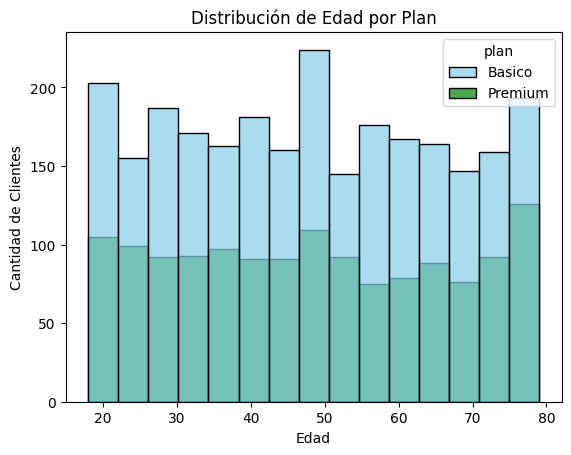

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan',
             palette=['skyblue', 'green'], bins=15, alpha=0.7)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()


Insights: Se puede visualizar que existe una mayor proporcion de personas de 50 años que utiliza el plan Basico, asi como una mayor proporcion de personas de 75 a 80 años, que cuenta con el plan premiun

Distribución simetrica, sin embargo se puede observar una ligera inclinación en caida de izquierda a derecha, lo que nos puede dar a entender, que una poblacion de 18 a 50 años, tiende a utilizar mas planes tanto basico como premiun, con la unica excepción de 75 a 80 años


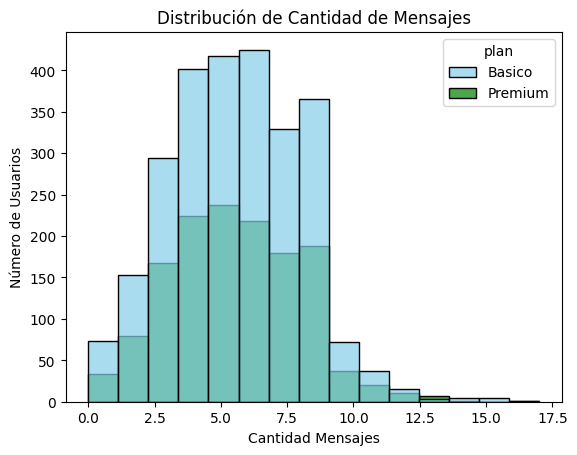

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',
             palette=['skyblue', 'green'], bins=15, alpha=0.7)
plt.title('Distribución de Cantidad de Mensajes')
plt.xlabel('Cantidad Mensajes')
plt.ylabel('Número de Usuarios')
plt.show()


Insights: Se puede confirmar, que las personas que usan plan basico, mandan muchos mas mensajes que las personas que usan premium, lo cual es curioso, siendo que a pesar de que son el publico que menos mensajes tiene al mes incluidos, son los que mayor provecho le dan, en comparacion con los que pagan mas mensualmente

La distribución muestra un sesgo hacia la derecha, lo cual es un comportamiento relativamente normal para este caso y presenta outliers superiores (usuarios que envían >12 mensajes)


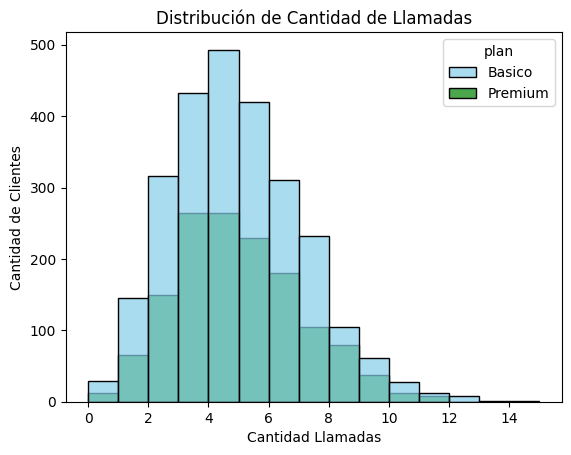

In [35]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',
             palette=['skyblue', 'green'], bins=15, alpha=0.7)
plt.title('Distribución de Cantidad de Llamadas')
plt.xlabel('Cantidad Llamadas')
plt.ylabel('Cantidad de Clientes')
plt.show()


Insights: Aqui podemos visualizar un poco de lo mismo de la anterior grafica pero con respecto a las llamadas y la diferencia de uso mayor en el plan basico al usuario del plan premiun, ademas de presentar outliers superiores (usuarios que hacen >10 llamadas)

La distribución muestra un sesgo hacia la derecha, lo cual es un comportamiento relativamente normal para este caso y la grafica


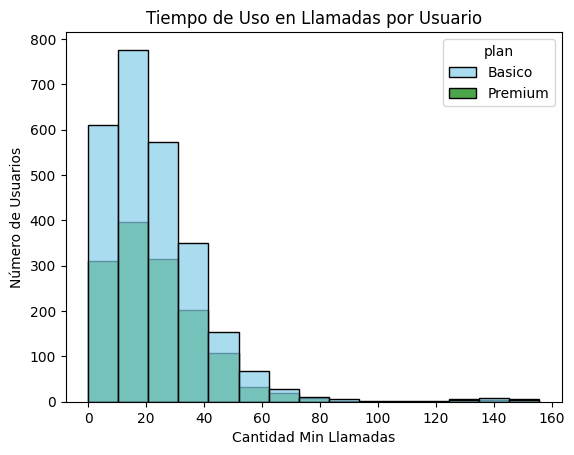

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue', 'green'], bins=15, alpha=0.7)
plt.title('Tiempo de Uso en Llamadas por Usuario')
plt.xlabel('Cantidad Min Llamadas')
plt.ylabel('Número de Usuarios')
plt.show()


Insights: Aqui presenta outliers superiores importantes (usuarios con >80 minutos) lo cual deberia tomarse en cuenta dado que estos usuarios podrían ser:

* Profesionales que usan el teléfono para trabajo
* Usuarios que hacen llamadas internacionales largas
* Personas que usan llamadas en lugar de mensajes
* Clientes que podrían beneficiarse de planes ilimitados
* La distribución muestra un sesgo hacia la derecha, lo cual es un comportamiento relativamente normal para este caso y la grafica, aunque con un ligero repunte al final.


Usar boxplots para identificar visualmente outliers en las siguientes columnas:
age
cant_mensajes
cant_llamadas
total_minutos_llamada

Detectar valores extremos en las variables clave de uso y clientes que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

/tmp/ipykernel_2414/1278505719.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


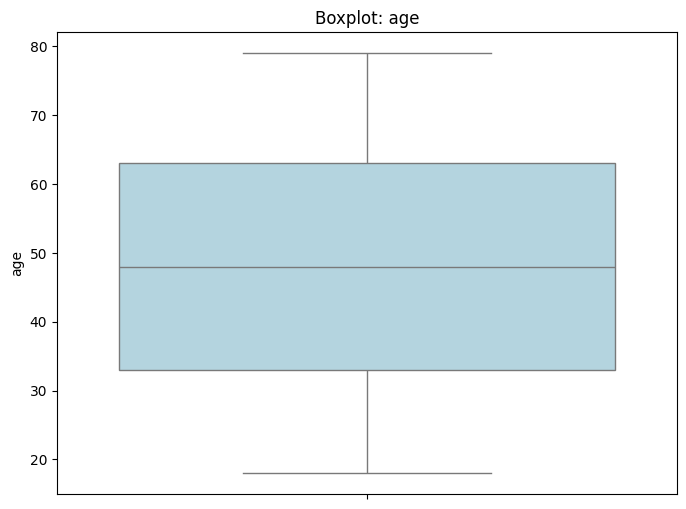

/tmp/ipykernel_2414/1278505719.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


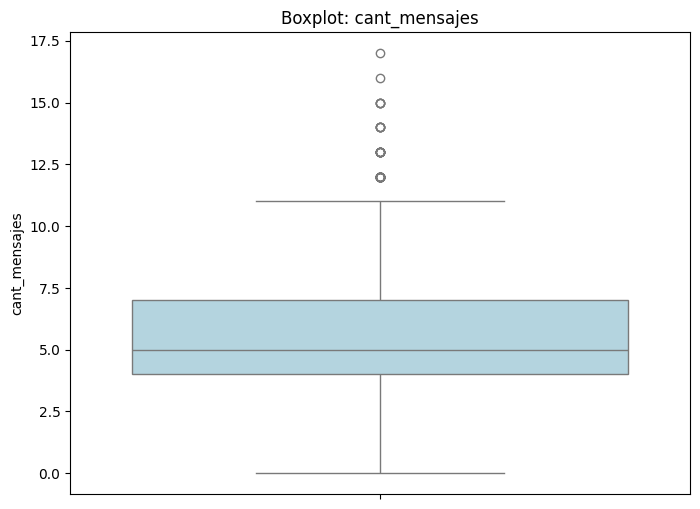

/tmp/ipykernel_2414/1278505719.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


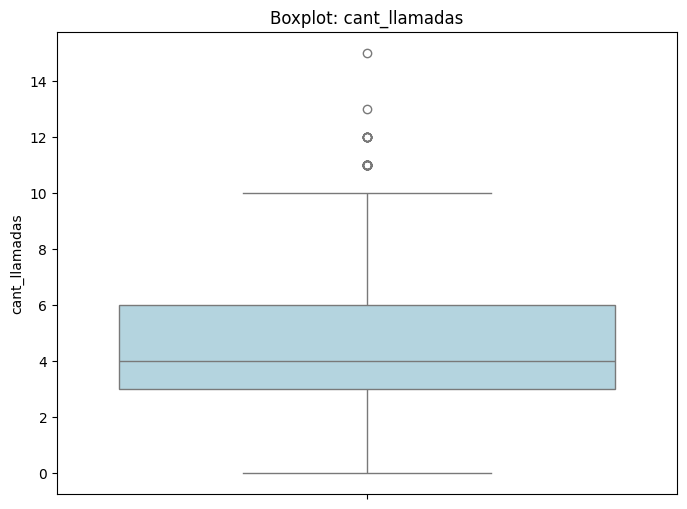

/tmp/ipykernel_2414/1278505719.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_profile, y=col, palette=['lightblue'])


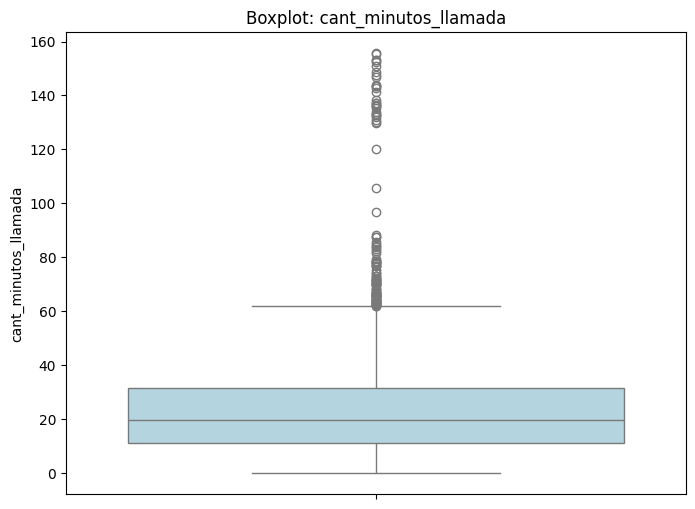

In [41]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=user_profile, y=col, palette=['lightblue'])
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()


Insights:

Age: No presenta outliers significativos, distribución normal
cant_mensajes: Presenta outliers superiores (usuarios que envían >12 mensajes)
cant_llamadas: Presenta outliers superiores (usuarios que hacen >10 llamadas)
cant_minutos_llamada: Presenta outliers superiores importantes (usuarios con >80 minutos casi 160)


In [42]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    print(f"=== {col} ===")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo actual: {user_profile[col].max():.2f}")
    print()


=== cant_mensajes ===
Q1: 4.00
Q3: 7.00
Límite superior: 11.50
Valor máximo actual: 17.00

=== cant_llamadas ===
Q1: 3.00
Q3: 6.00
Límite superior: 10.50
Valor máximo actual: 15.00

=== cant_minutos_llamada ===
Q1: 11.12
Q3: 31.41
Límite superior: 61.86
Valor máximo actual: 155.69



In [43]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


- cant_mensajes: mantener o no outliers, porqué? Mantener, Los outliers (>11.5 mensajes) representan usuarios con comportamiento de uso intensivo real, en telecomunicaciones, es común tener usuarios que envían muchos mensajes y estos usuarios son valiosos comercialmente (mayor engagement, posibles candidatos para planes premium), siendo asi, los valores máximos (17 mensajes) son realistas y no parecen errores de datos
- cant_llamadas: mantener o no outliers, porqué? Mantener, Similar al caso anterior, usuarios con >10.5 llamadas representan patrones de uso legítimos, podrían ser profesionales, personas que prefieren llamar vs. mensajear, o usuarios de negocios, estos son segmentos importantes para estrategias comerciales diferenciadas y el máximo de 15 llamadas es perfectamente creible
- cant_minutos_llamada: mantener o no outliers, porqué? Investigar y posiblemente mantener, Los outliers aquí son más extremos (>61.86 minutos, máximo 155.69) sin embargo, podrían representar: usuarios de negocios con llamadas largas, personas que hacen llamadas internacionales o usuarios que prefieren llamadas sobre otros medios


Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

In [45]:
# Crear columna grupo_uso
def clasificar_uso(llamadas, mensajes):
    """
    Función para clasificar usuarios según su uso de llamadas y mensajes
    """
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar la función para crear la columna grupo_uso
user_profile['grupo_uso'] = user_profile.apply(
    lambda row: clasificar_uso(row['cant_llamadas'], row['cant_mensajes']),
    axis=1
)



In [46]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


 Clasificar a cada usuario en un grupo por edad.

In [47]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    """
    Función para clasificar usuarios según su edad
    """
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicar la función para crear la columna grupo_edad
user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [48]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


Visualizar la distribución de los usuarios según los grupos creados: grupo_uso y grupo_edad.

/tmp/ipykernel_2414/1801454498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_uso', palette=['lightcoral', 'lightblue', 'lightgreen'])


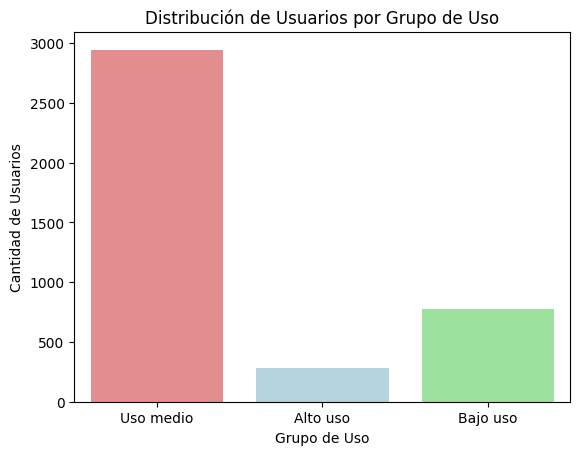

In [49]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', palette=['lightcoral', 'lightblue', 'lightgreen'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


/tmp/ipykernel_2414/1835801202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=user_profile, x='grupo_edad', palette=['gold', 'skyblue', 'salmon'])


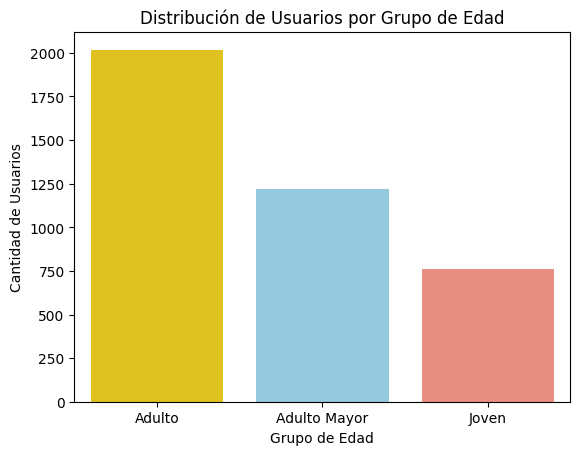

In [50]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['gold', 'skyblue', 'salmon'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


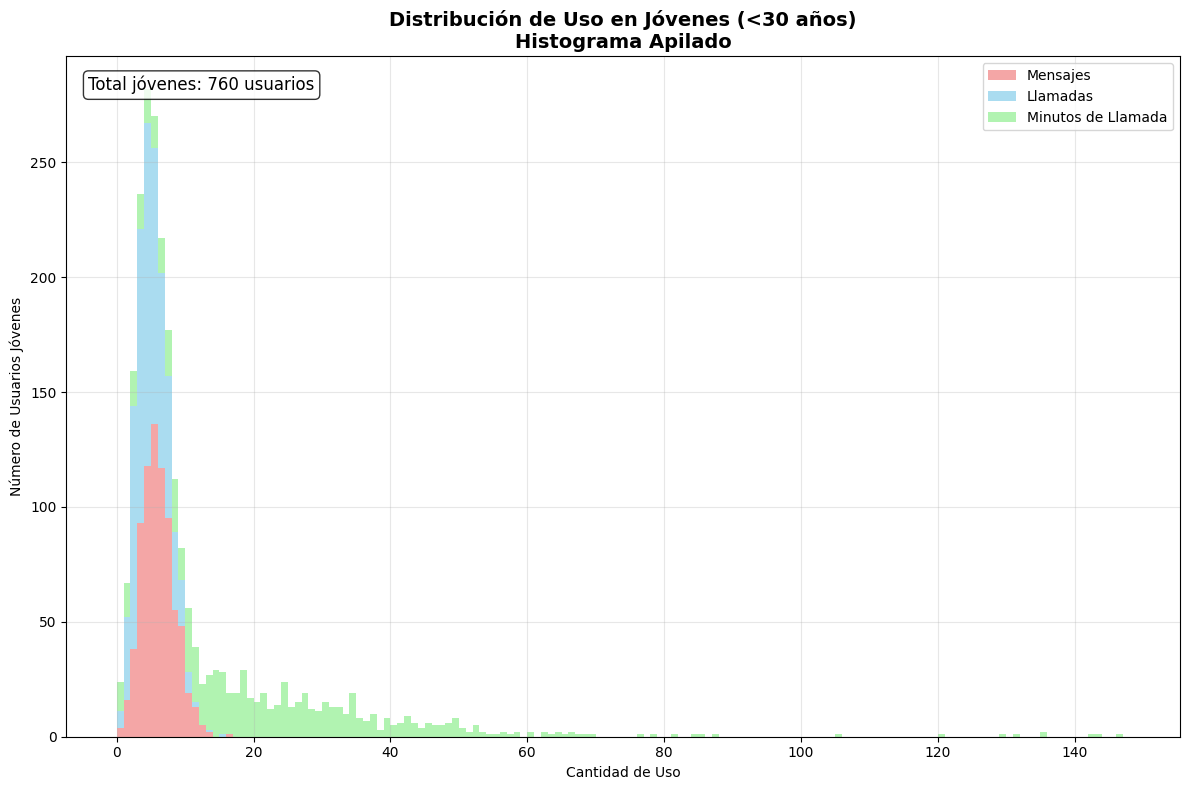

In [51]:
#Histograma Apilado para Jóvenes
# Filtrar datos para el grupo de jóvenes
jovenes = user_profile[user_profile['grupo_edad'] == 'Joven']

# Crear bins para el histograma
bins = np.arange(0, max(jovenes['cant_mensajes'].max(),
                       jovenes['cant_llamadas'].max(),
                       jovenes['cant_minutos_llamada'].max()) + 2)

# Crear el histograma apilado
plt.figure(figsize=(12, 8))

plt.hist([jovenes['cant_mensajes'],
          jovenes['cant_llamadas'],
          jovenes['cant_minutos_llamada']],
         bins=bins,
         label=['Mensajes', 'Llamadas', 'Minutos de Llamada'],
         alpha=0.7,
         color=['lightcoral', 'skyblue', 'lightgreen'],
         stacked=True)

# Personalizar el gráfico
plt.title('Distribución de Uso en Jóvenes (<30 años)\nHistograma Apilado',
          fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Uso')
plt.ylabel('Número de Usuarios Jóvenes')
plt.legend()
plt.grid(True, alpha=0.3)

# Agregar estadísticas
plt.text(0.02, 0.95, f'Total jóvenes: {len(jovenes)} usuarios',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()


In [52]:
# Mostrar estadísticas descriptivas para jóvenes
print("=== ESTADÍSTICAS DE USO EN JÓVENES ===")
print(f"Cantidad total de jóvenes: {len(jovenes)}")
print("\nPromedio de uso:")
print(f"Mensajes: {jovenes['cant_mensajes'].mean():.2f}")
print(f"Llamadas: {jovenes['cant_llamadas'].mean():.2f}")
print(f"Minutos: {jovenes['cant_minutos_llamada'].mean():.2f}")

print("\nDistribución de planes en jóvenes:")
print(jovenes['plan'].value_counts(normalize=True) * 100)


=== ESTADÍSTICAS DE USO EN JÓVENES ===
Cantidad total de jóvenes: 760

Promedio de uso:
Mensajes: 5.52
Llamadas: 4.43
Minutos: 23.75

Distribución de planes en jóvenes:
plan
Basico     63.947368
Premium    36.052632
Name: proportion, dtype: float64


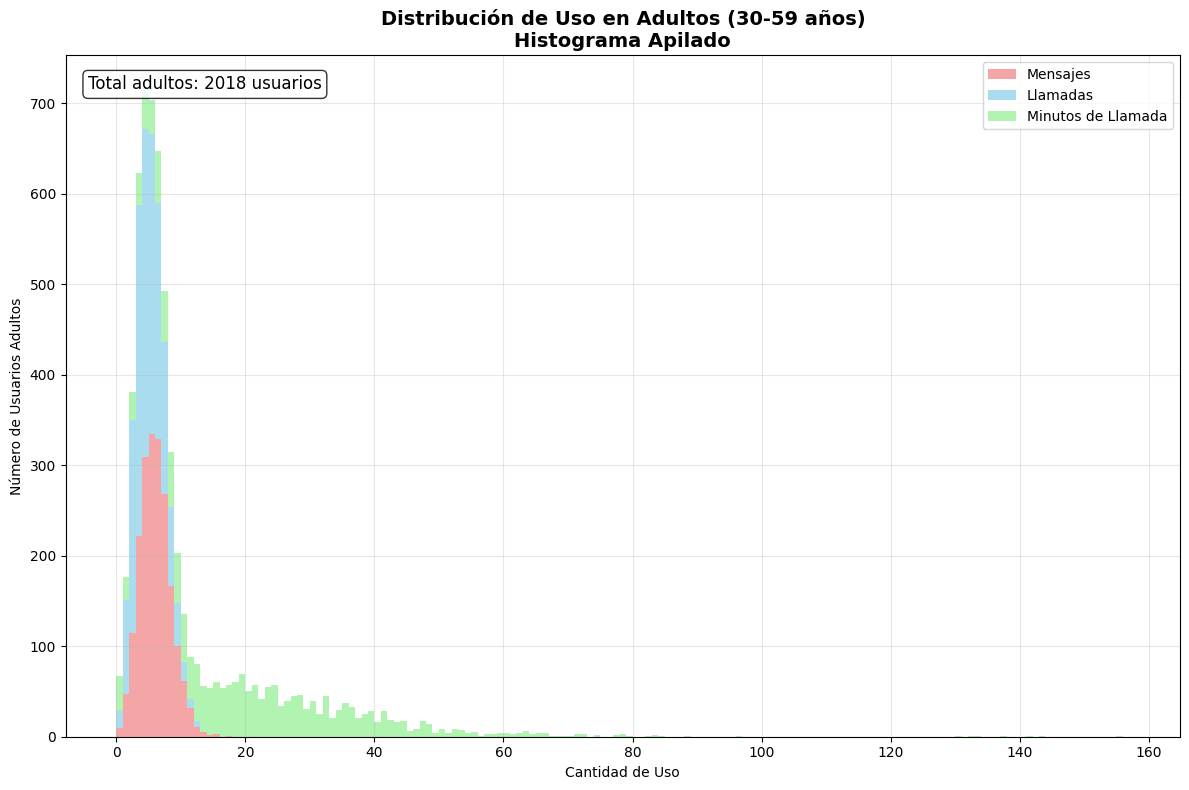

In [53]:
#Histograma Apilado para Adultos
# Filtrar datos para el grupo de adultos
adultos = user_profile[user_profile['grupo_edad'] == 'Adulto']

# Crear bins para el histograma
bins_adultos = np.arange(0, max(adultos['cant_mensajes'].max(),
                               adultos['cant_llamadas'].max(),
                               adultos['cant_minutos_llamada'].max()) + 2)

# Crear el histograma apilado para adultos
plt.figure(figsize=(12, 8))

plt.hist([adultos['cant_mensajes'],
          adultos['cant_llamadas'],
          adultos['cant_minutos_llamada']],
         bins=bins_adultos,
         label=['Mensajes', 'Llamadas', 'Minutos de Llamada'],
         alpha=0.7,
         color=['lightcoral', 'skyblue', 'lightgreen'],
         stacked=True)

# Personalizar el gráfico
plt.title('Distribución de Uso en Adultos (30-59 años)\nHistograma Apilado',
          fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Uso')
plt.ylabel('Número de Usuarios Adultos')
plt.legend()
plt.grid(True, alpha=0.3)

# Agregar estadísticas
plt.text(0.02, 0.95, f'Total adultos: {len(adultos)} usuarios',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

In [54]:
# Filtrar datos para adultos
adultos = user_profile[user_profile['grupo_edad'] == 'Adulto']

# Mostrar estadísticas descriptivas para adultos
print("=== ESTADÍSTICAS DE USO EN ADULTOS ===")
print(f"Cantidad total de adultos: {len(adultos)}")
print("\nPromedio de uso:")
print(f"Mensajes: {adultos['cant_mensajes'].mean():.2f}")
print(f"Llamadas: {adultos['cant_llamadas'].mean():.2f}")
print(f"Minutos: {adultos['cant_minutos_llamada'].mean():.2f}")

print("\nDistribución de planes en adultos:")
print(adultos['plan'].value_counts(normalize=True) * 100)


=== ESTADÍSTICAS DE USO EN ADULTOS ===
Cantidad total de adultos: 2018

Promedio de uso:
Mensajes: 5.55
Llamadas: 4.48
Minutos: 23.00

Distribución de planes en adultos:
plan
Basico     65.659068
Premium    34.340932
Name: proportion, dtype: float64


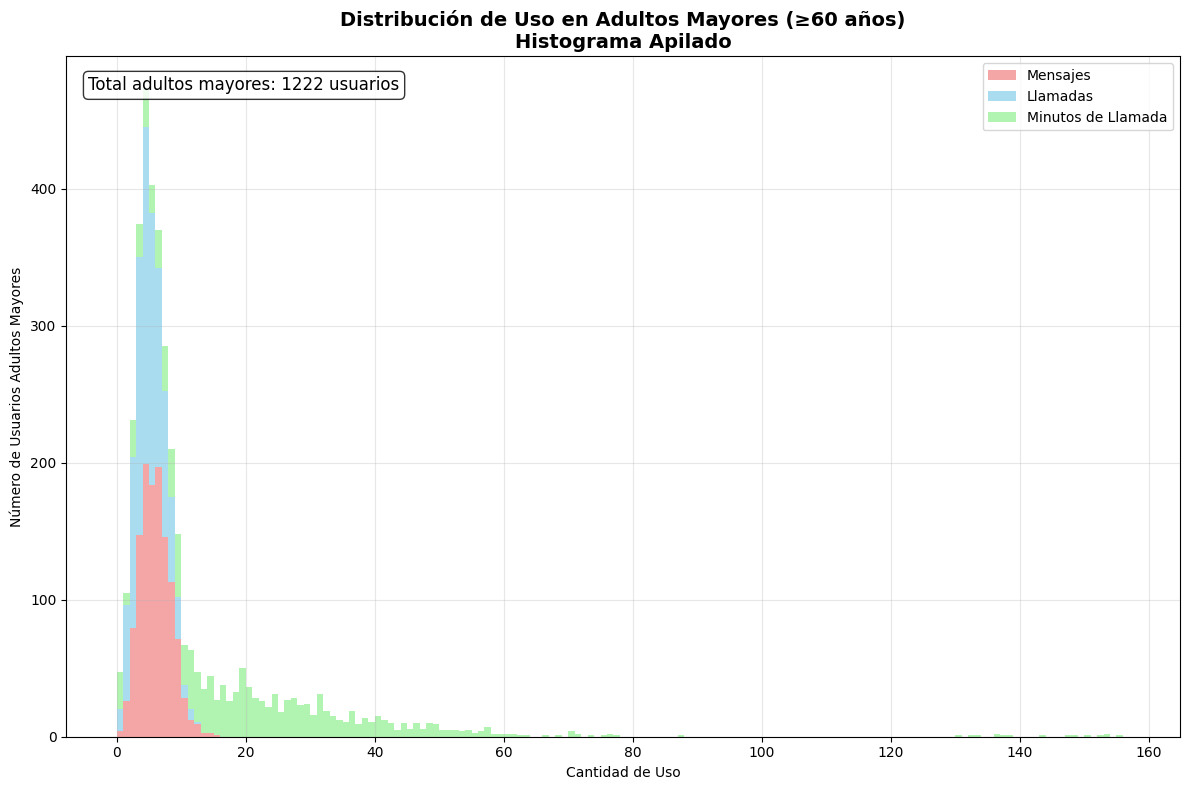

In [55]:
# Histograma Apilado para Adultos Mayores
# Filtrar datos para el grupo de adultos mayores
adultos_mayores = user_profile[user_profile['grupo_edad'] == 'Adulto Mayor']

# Crear bins para el histograma
bins_mayores = np.arange(0, max(adultos_mayores['cant_mensajes'].max(),
                               adultos_mayores['cant_llamadas'].max(),
                               adultos_mayores['cant_minutos_llamada'].max()) + 2)

# Crear el histograma apilado para adultos mayores
plt.figure(figsize=(12, 8))

plt.hist([adultos_mayores['cant_mensajes'],
          adultos_mayores['cant_llamadas'],
          adultos_mayores['cant_minutos_llamada']],
         bins=bins_mayores,
         label=['Mensajes', 'Llamadas', 'Minutos de Llamada'],
         alpha=0.7,
         color=['lightcoral', 'skyblue', 'lightgreen'],
         stacked=True)

# Personalizar el gráfico
plt.title('Distribución de Uso en Adultos Mayores (≥60 años)\nHistograma Apilado',
          fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Uso')
plt.ylabel('Número de Usuarios Adultos Mayores')
plt.legend()
plt.grid(True, alpha=0.3)

# Agregar estadísticas
plt.text(0.02, 0.95, f'Total adultos mayores: {len(adultos_mayores)} usuarios',
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

In [56]:
# Filtrar datos para adultos mayores
adultos_mayores = user_profile[user_profile['grupo_edad'] == 'Adulto Mayor']

# Mostrar estadísticas descriptivas para adultos mayores
print("=== ESTADÍSTICAS DE USO EN ADULTOS MAYORES ===")
print(f"Cantidad total de adultos mayores: {len(adultos_mayores)}")
print("\nPromedio de uso:")
print(f"Mensajes: {adultos_mayores['cant_mensajes'].mean():.2f}")
print(f"Llamadas: {adultos_mayores['cant_llamadas'].mean():.2f}")
print(f"Minutos: {adultos_mayores['cant_minutos_llamada'].mean():.2f}")

print("\nDistribución de planes en adultos mayores:")
print(adultos_mayores['plan'].value_counts(normalize=True) * 100)


=== ESTADÍSTICAS DE USO EN ADULTOS MAYORES ===
Cantidad total de adultos mayores: 1222

Promedio de uso:
Mensajes: 5.49
Llamadas: 4.50
Minutos: 23.58

Distribución de planes en adultos mayores:
plan
Basico     64.157119
Premium    35.842881
Name: proportion, dtype: float64


In [57]:
print("=== COMPARACIÓN: PROMEDIOS vs MEDIANAS ===")
for grupo in ['Joven', 'Adulto', 'Adulto Mayor']:
    datos = user_profile[user_profile['grupo_edad'] == grupo]
    print(f"\n{grupo}:")
    print(f"Mensajes - Promedio: {datos['cant_mensajes'].mean():.2f}, Mediana: {datos['cant_mensajes'].median():.2f}")
    print(f"Minutos - Promedio: {datos['cant_minutos_llamada'].mean():.2f}, Mediana: {datos['cant_minutos_llamada'].median():.2f}")


=== COMPARACIÓN: PROMEDIOS vs MEDIANAS ===

Joven:
Mensajes - Promedio: 5.52, Mediana: 5.00
Minutos - Promedio: 23.75, Mediana: 19.16

Adulto:
Mensajes - Promedio: 5.55, Mediana: 5.00
Minutos - Promedio: 23.00, Mediana: 20.04

Adulto Mayor:
Mensajes - Promedio: 5.49, Mediana: 5.00
Minutos - Promedio: 23.58, Mediana: 19.66


Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

Análisis ejecutivo
**Problemas detectados en los datos**

Valores sentinels y datos inválidos: Age: 40 usuarios tenían el valor sentinel -999 (1% de los datos) City: 96 usuarios tenían "?" como valor inválido (2.4% de los datos) Fechas imposibles: 40 registros con fechas en 2026 (1% de reg_date)

Valores nulos estructurales: Duration/Length en usage: 99.93% de nulos en cada columna, pero eran Missing At Random (MAR) - los mensajes no tienen duración y las llamadas no tienen longitud

**Segmentos por Edad**

Jóvenes (<30): Los jovenes apesar de que se concentran en menor cantidad a comparacion de los demas, tienden a tener outliers en cantidad de minutos por llamada, a pesas de que estos sean los que tiene un plan basico mayormente en lugar de premium, esto incluso pudiera deberse a otros factores, como el poder adquisitivo e incluso estar orillados a solamente poder aprovechar de esta manera de minutos de llamadas, dada la poca variedad de planes para solo llamar, dado que estos tienden tambien a mandar menos mensajes que los demas, se puede deber a que estos hac
en mas uso de internet u otras herramientas de mensajeria, mas alla del modo tradicional de mandar mensajes.

Adultos (30-59): Grupo mayoritario, existe una concentración mayor en el grupo "Adulto" por lo que la mayoria de usuarios que se concentra en un uso regular o medio de su plan se encuentre en este segmento de edad, estos son los clientes mas leales y que da mas uso a la mayorias de los servicios, a la par se puedan brindar mejores beneficios para mantener la lealtad a la marca con el paso del tiempo

Adultos mayores (≥60): Estos al contar con mayor disponibilidad tanto de tiempo como de poder adquisitivos, son un segmento premium, sin embargo dados factores como la adaptabilidad a la tecnologia como al conocimiento de los servicios e incluso el menor uso de aparatos electronicos por costumbres que permanecen en las personas de dicha generación, mandan mas mensajes que los jovenes y llegan a empatar con la cantidad de minutos de llamada con estos mismos, sin embargo no mandan la misma cantidad de mensajes que los adultos, esto se puede deber a que porqlos adultos tienden a usarlo tambien mas por negocios o trabajo y aqui es mayormente por socializar y comunicarse con su allegados

Esto sugiere que existen patrones de edad que sugieren mayor lealtad

**Segmentos por Nivel de Uso**

*Bajo uso: Usuarios con <5 llamadas Y <5 mensajes
*Uso medio: Usuarios con <10 llamadas Y <10 mensajes
*Alto uso: El resto (usuarios intensivos) Mensajes: >11.5 mensajes (máximo 17) Llamadas: >10.5 llamadas (máximo 15) Minutos: >61.86 minutos (máximo 155.69)

Esto sugiere que los usuarios del plan Básico paradójicamente usan MÁS los servicios que los Premium, los usuarios de alto uso podrían pagar más o tener algun otro tipo de plan mas personalizado, asi como usuarios Premium que no aprovechan su plan.

**Recomendaciones**

*Reestructuración de Planes Actuales*:
Los usuarios Básico efectivamente usan MÁS servicios que los Premium
Plan Básico: 64.88% de usuarios, pero con mayor uso promedio Plan Premium: 35.12% de usuarios, con menor aprovechamiento

*Revisar estructura de precios*:
El plan Premium no está justificando su valor Crear incentivos de migración: Ofertas especiales para usuarios Básico de alto uso (>10 llamadas, >11 mensajes) Optimizar beneficios Premium: Agregar servicios que realmente valoren

**Nuevos Planes Segmentados por Edad**

Plan "Joven" (<30 años): Jóvenes usan más minutos de llamada de lo esperado (23.75 min promedio) Características: Más minutos incluidos, menos mensajes tradicionales Precio: Competitivo para captar este segmento (36% ya usa Premium)

Plan "Adulto" (30-59 años): Grupo mayoritario (50.5%) con uso equilibrado Características: Plan estándar optimizado, balance mensajes-llamadas Estrategia: Fidelización y upselling gradual

Plan "Senior" (≥60 años): Uso similar a jóvenes pero diferente comportamiento Características: Más soporte, servicios simplificados Precio: Premium justificado con servicios de valor agregado

**Estrategias por Nivel de Uso**

Usuarios de Alto Uso (outliers identificados): Mensajes >11.5:

Plan "Comunicador" con mensajes ilimitados Llamadas >10.5

Plan "Profesional" con llamadas ilimitadas Minutos >61.86: Plan "Business" con tarifas preferenciales

Usuarios de Bajo/Medio Uso:
Plan "Básico Light": Más económico para retener usuarios de bajo uso Flexibilidad: Opciones de pago por uso adicional

Aprovechamiento de Insights Específicos
Paradoja del Plan Básico:

Campaña de educación: Mostrar a usuarios Básico el valor del Premium Pruebas gratuitas: 30 días de Premium para usuarios de alto uso en Básico Planes híbridos: Básico+ con algunos beneficios Premium Distribución por Edad Equilibrada:

Marketing segmentado: Estrategias específicas por grupo etario Canales diferenciados: Digital para jóvenes, tradicional para mayores

Métricas de Seguimiento Recomendadas
*Tasa de migración de Básico a Premium por grupo de edad*
*Uso promedio por plan después de implementar cambios*
*Satisfacción de usuarios con outliers de uso*
*Retención por segmento de edad y uso*